In [31]:
%pip install folium pandas OSMnx networkx scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


# Capacity

/tmp/ipykernel_101649/181514259.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [cm.get_cmap('YlOrRd')(norm(value)) for value in seq]


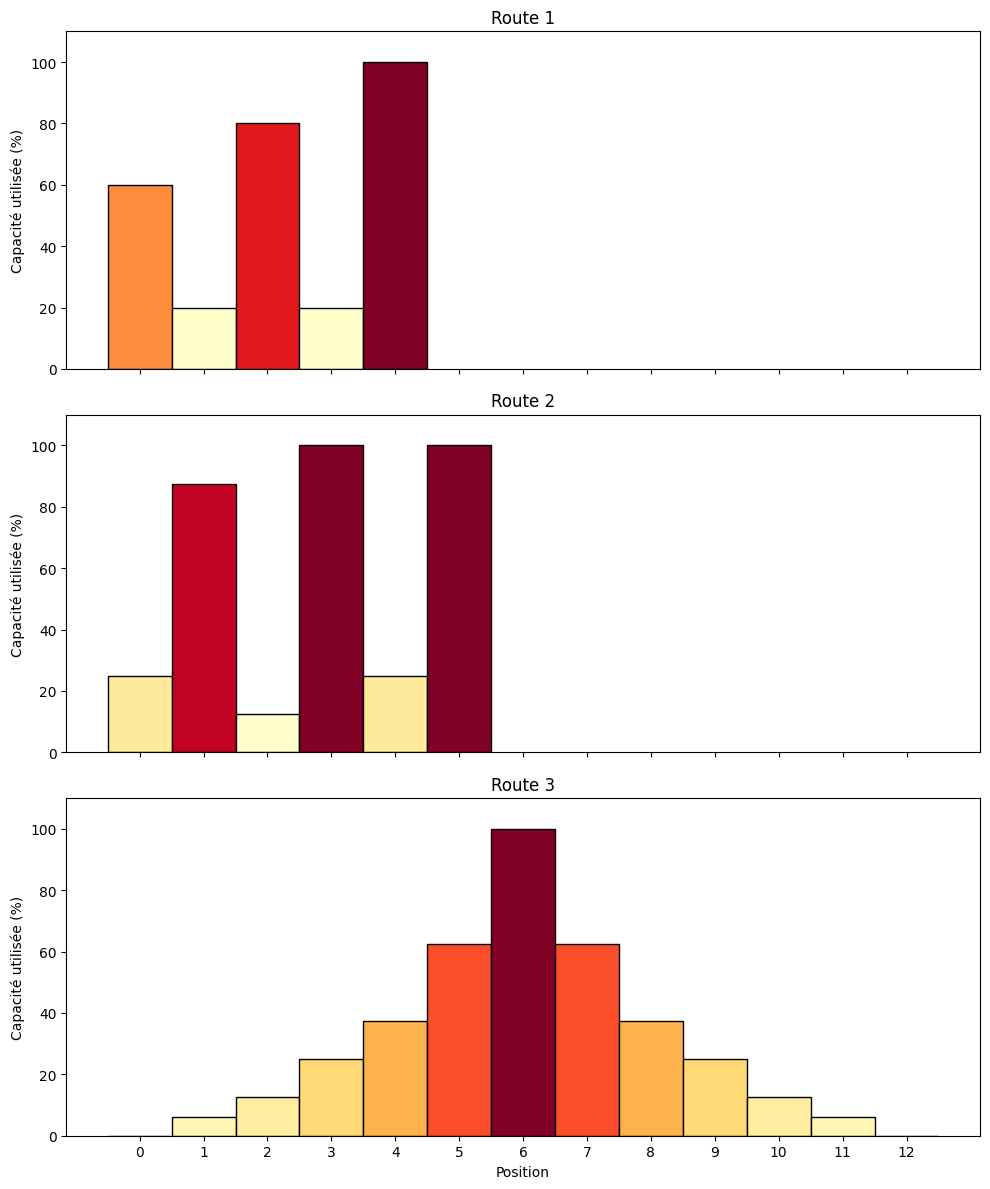

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_number_columns(*sequences):
    num_sequences = len(sequences)
    fig, axes = plt.subplots(num_sequences, 1, figsize=(10, num_sequences * 4), sharex=True)
    
    if num_sequences == 1:
        axes = [axes]
    
    for i, (ax, seq) in enumerate(zip(axes, sequences)):

        max_value = max(seq) # TODO prendre la capacity value de l'instance
        
        normalized_seq = [value / max_value * 100 for value in seq]  # Normalisation en %
        x_positions = np.arange(len(seq))
        
        # Couleur
        norm = mcolors.Normalize(vmin=min(seq), vmax=max(seq))
        colors = [cm.get_cmap('YlOrRd')(norm(value)) for value in seq]
        
        ax.bar(x_positions, normalized_seq, color=colors, edgecolor='black', width=1.0)  # Largeur des colonnes = 1.0 pour les coller
        ax.set_ylabel('Capacité utilisée (%)')
        ax.set_title(f'Route {i+1}')
        ax.set_ylim(0, 110)
        ax.set_xticks(x_positions)  # TODO Ecrire les position (locationID) pour chaque graphique
    
    axes[-1].set_xlabel('Position')
    plt.tight_layout()
    plt.show()

# test
plot_number_columns([3, 1, 4, 1, 5], [2, 7, 1, 8, 2, 8], [0, 0.5,1,2,3,5,8,5,3,2,1, 0.5, 0])